# Bayesian Neural Networks for Federated Learning over Wireless Channels

This notebook is a **research-starting template** built presentation focus and the authors' companion repositories for *Hands-on Bayesian Neural Networks -- A Tutorial for Deep Learning Users*.

The goal is not to reproduce the full paper repository exactly. Instead, it gives a **self-contained notebook** that covers the pieces most relevant to planned research:

$$
\boxed{
\text{Hierarchical Bayesian FL}
+
\text{last-layer BNN}
+
\text{VI / MC-Dropout intuition}
+
\text{wireless noisy-update model}
}
$$

The code uses only **NumPy** and **Matplotlib** so that it can run in a basic Jupyter environment. It avoids `sklearn`, `pyro`, and large datasets.

## 0. How this notebook maps to the paper and repository

### Paper concepts used here

| Paper concept | Notebook implementation |
|---|---|
| Functional model $\Phi_\theta(x)$ | Random nonlinear feature extractor plus Bayesian last layer |
| Stochastic model | Gaussian prior over final-layer weights and Gaussian likelihood |
| Posterior $p(\theta \mid D)$ | Closed-form Bayesian linear-regression posterior for each client |
| Algorithm 1 inference | Sample / average predictions from posterior distributions |
| Hierarchical Bayes / meta-learning | Global model aggregates client-specific posteriors |
| MC-Dropout | Random feature masks at test time to simulate stochastic subnetworks |
| Wireless uncertainty | Noisy transmitted client update $\widetilde{\Delta}_{k,t} = h_{k,t}\Delta_{k,t} + n_{k,t}$ |

### Repository parts this notebook is inspired by

The tutorial's meta-repository points to practical examples. For research direction, the most useful pieces are:

1. `sparse_measure_bnn/viModel.py`  
   Important ideas: `VIModule`, Gaussian-prior regularization, mean-field Gaussian variational layers, last-layer Bayesian modeling, MC-Dropout, and outlier-aware loss.

2. `paperfold-bnn`  
   Important ideas: comparing MCMC, variational inference, MAP/Laplace-style approximations, deep ensembles, and posterior visualization.

This notebook reimplements the most relevant ideas in a compact FL/wireless setting rather than requiring the full repositories.

## 1. Research PGM: Hierarchical Bayesian Federated Learning with Wireless Updates

A natural Bayesian FL model is:

$$
\xi \sim p(\xi),
$$

$$
\theta_k \sim p(\theta_k \mid \xi),
$$

$$
D_k \sim p(D_k \mid \theta_k),
$$

where:

$$
\xi = \text{global server-level knowledge},
$$

$$
\theta_k = \text{client-specific model parameter},
$$

$$
D_k = \text{local dataset of client } k.
$$

The posterior is:

$$
p\left(\xi, \{\theta_k\}_{k=1}^{K} \mid \{D_k\}_{k=1}^{K}\right)
\propto
p(\xi)
\prod_{k=1}^{K}
p(\theta_k \mid \xi)
p(D_k \mid \theta_k).
$$

For wireless FL, the server often receives a corrupted local update:

$$
\widetilde{\Delta}_{k,t}
=
h_{k,t}\Delta_{k,t} + n_{k,t},
\qquad
n_{k,t} \sim \mathcal{N}(0, \sigma_{\mathrm{ch},k,t}^2 I).
$$

After equalization:

$$
\widehat{\Delta}_{k,t}
=
\frac{\widetilde{\Delta}_{k,t}}{h_{k,t}}
=
\Delta_{k,t} + \frac{n_{k,t}}{h_{k,t}}.
$$

So worse channel quality increases the effective uncertainty:

$$
\operatorname{Var}\left(\frac{n_{k,t}}{h_{k,t}}\right)
=
\frac{\sigma_{\mathrm{ch},k,t}^2}{h_{k,t}^2}.
$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("NumPy version:", np.__version__)


Matplotlib is building the font cache; this may take a moment.


NumPy version: 2.3.5


## 2. Synthetic non-IID federated regression data

We create several clients. Each client observes a different region of the input space and may have a small client-specific bias. This simulates **non-IID data**, a common challenge in Federated Learning.

The global hidden function is:

$$
f(x) = \sin(x) + 0.3\cos(2x).
$$

Client $k$ observes:

$$
y_{k,i} = f(x_{k,i}) + b_k + \epsilon_{k,i},
\qquad
\epsilon_{k,i} \sim \mathcal{N}(0, \sigma_k^2).
$$

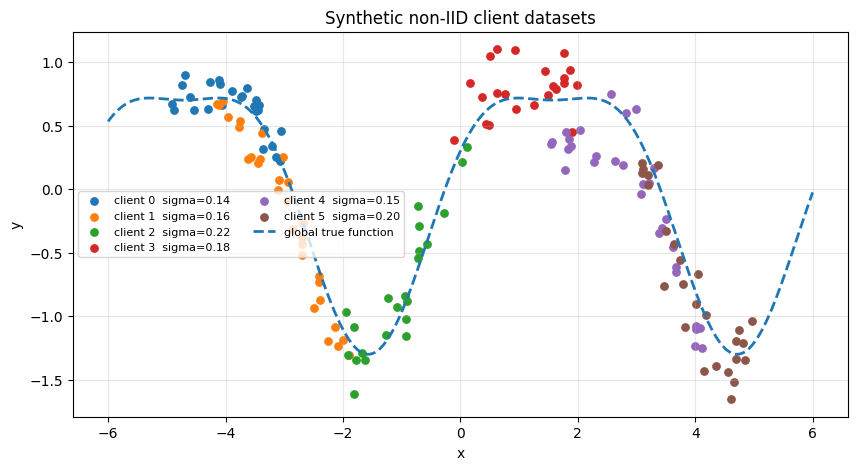

In [2]:
def true_function(x):
    return np.sin(x) + 0.3 * np.cos(2 * x)

K = 6
client_ranges = [(-5.0, -3.0), (-4.2, -1.5), (-2.0, 0.2), (-0.2, 2.0), (1.5, 4.2), (3.0, 5.0)]
n_per_client = [26, 30, 22, 22, 30, 26]
client_biases = rng.normal(0.0, 0.12, size=K)
client_noise = np.array([0.14, 0.16, 0.22, 0.18, 0.15, 0.20])

clients = []
for k, ((lo, hi), n, bias, sigma) in enumerate(zip(client_ranges, n_per_client, client_biases, client_noise)):
    x = np.sort(rng.uniform(lo, hi, size=n))
    y = true_function(x) + bias + rng.normal(0, sigma, size=n)
    clients.append({"id": k, "x": x, "y": y, "bias": bias, "sigma": sigma, "range": (lo, hi)})

x_grid = np.linspace(-6, 6, 500)
y_true = true_function(x_grid)

plt.figure(figsize=(10, 5))
for c in clients:
    plt.scatter(c["x"], c["y"], s=28, label=f"client {c['id']}  sigma={c['sigma']:.2f}")
plt.plot(x_grid, y_true, linestyle="--", linewidth=2, label="global true function")
plt.title("Synthetic non-IID client datasets")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(ncol=2, fontsize=8)
plt.show()


## 3. Functional model: random nonlinear features + Bayesian last layer

The recommended research direction is a **last-layer BNN**. This is computationally cheaper than putting a posterior over every neural-network layer.

We use a fixed nonlinear feature map:

$$
\Phi(x) = \left[1, \tanh(w_1x+b_1),\ldots,\tanh(w_Mx+b_M)\right].
$$

Then only the final-layer weights are Bayesian:

$$
y = \Phi(x)^T\theta + \epsilon.
$$

Prior:

$$
\theta \sim \mathcal{N}(0,\sigma_0^2I).
$$

Likelihood for client $k$:

$$
y_k \mid x_k,\theta_k \sim \mathcal{N}(\Phi(x_k)^T\theta_k,\sigma_k^2).
$$

In [3]:
M = 45  # number of nonlinear features
feature_w = rng.normal(0.0, 0.85, size=M)
feature_b = rng.uniform(-3.0, 3.0, size=M)


def feature_map(x):
    # Return Phi(x) with shape (N, 1 + M).
    x = np.asarray(x).reshape(-1)
    hidden = np.tanh(np.outer(x, feature_w) + feature_b)
    return np.column_stack([np.ones_like(x), hidden])

Phi_grid = feature_map(x_grid)
d = Phi_grid.shape[1]

print("Number of Bayesian last-layer parameters d =", d)


Number of Bayesian last-layer parameters d = 46


## 4. Local Bayesian posterior for each client

For each client, the last-layer posterior is available in closed form because this is Bayesian linear regression on top of fixed nonlinear features.

For client $k$, let:

$$
\Phi_k = \Phi(D_{k,x}),
\qquad
\mathbf{y}_k = D_{k,y}.
$$

With prior:

$$
\theta_k \sim \mathcal{N}(0,\sigma_0^2I),
$$

and likelihood noise $\sigma_k^2$, the posterior is:

$$
p(\theta_k \mid D_k) = \mathcal{N}(\mu_k,\Sigma_k),
$$

where:

$$
\Sigma_k
=
\left(
\frac{1}{\sigma_0^2}I
+
\frac{1}{\sigma_k^2}\Phi_k^T\Phi_k
\right)^{-1},
$$

$$
\mu_k
=
\Sigma_k
\frac{1}{\sigma_k^2}\Phi_k^T\mathbf{y}_k.
$$

This is a clean version of the paper's idea:

$$
p(\theta \mid D)
\propto
p(D \mid \theta)p(\theta).
$$

In [4]:
prior_sigma = 1.0
prior_var = prior_sigma**2


def bayesian_last_layer_posterior(Phi, y, noise_sigma, prior_var=1.0):
    # Closed-form posterior for Bayesian linear regression.
    noise_var = noise_sigma**2
    d = Phi.shape[1]
    precision = np.eye(d) / prior_var + (Phi.T @ Phi) / noise_var
    Sigma = np.linalg.inv(precision)
    mu = Sigma @ (Phi.T @ y / noise_var)
    return mu, Sigma


def posterior_predictive(Phi, mu, Sigma, noise_sigma=None):
    # Return predictive mean and epistemic variance. Add noise variance if requested.
    mean = Phi @ mu
    epistemic_var = np.sum((Phi @ Sigma) * Phi, axis=1)
    if noise_sigma is not None:
        return mean, epistemic_var + noise_sigma**2, epistemic_var
    return mean, epistemic_var

for c in clients:
    Phi_c = feature_map(c["x"])
    mu, Sigma = bayesian_last_layer_posterior(Phi_c, c["y"], c["sigma"], prior_var=prior_var)
    c["Phi"] = Phi_c
    c["mu"] = mu
    c["Sigma"] = Sigma
    c["posterior_std_diag"] = np.sqrt(np.diag(Sigma))

print("Computed local Bayesian last-layer posterior for", K, "clients.")


Computed local Bayesian last-layer posterior for 6 clients.


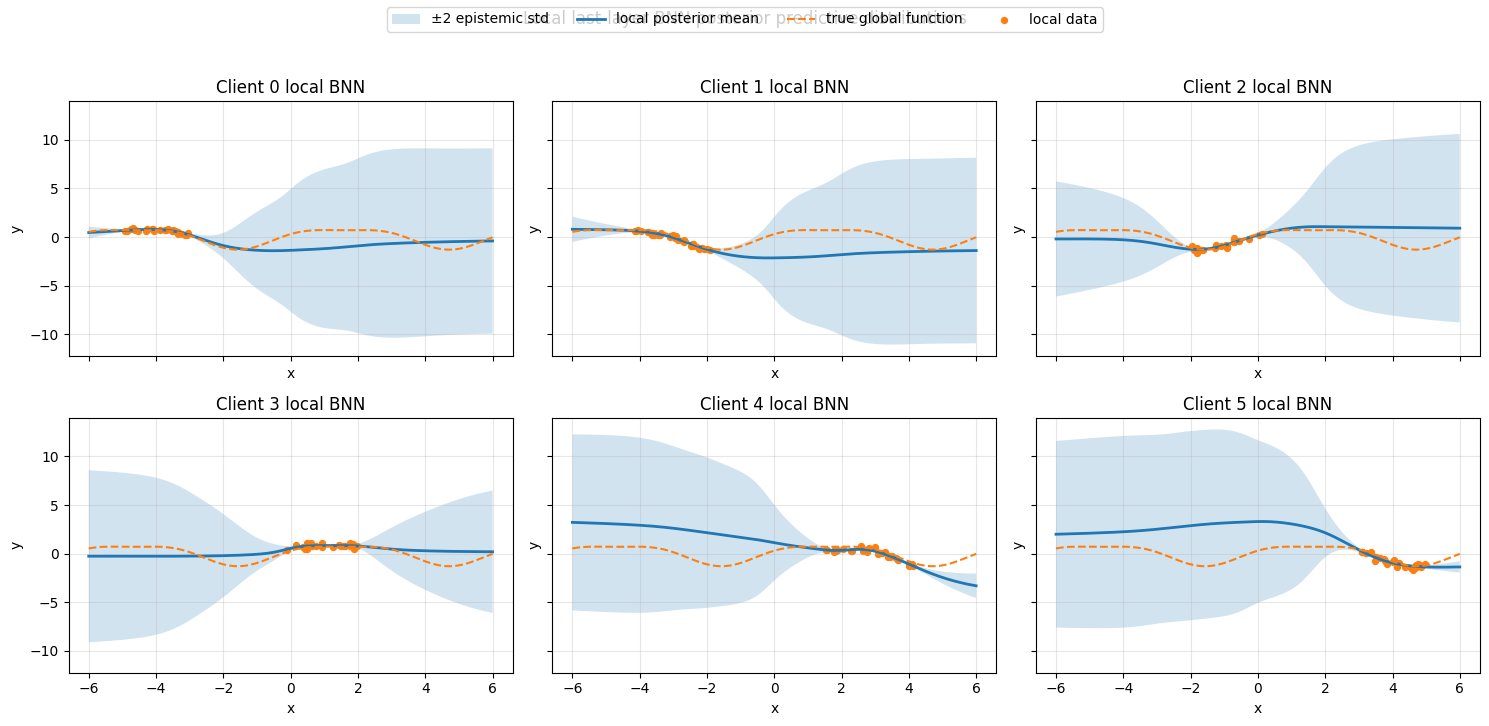

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True, sharey=True)
axes = axes.ravel()

for ax, c in zip(axes, clients):
    mean, total_var, epi_var = posterior_predictive(Phi_grid, c["mu"], c["Sigma"], noise_sigma=c["sigma"])
    epi_std = np.sqrt(epi_var)
    ax.fill_between(x_grid, mean - 2 * epi_std, mean + 2 * epi_std, alpha=0.2, label="±2 epistemic std")
    ax.plot(x_grid, mean, linewidth=2, label="local posterior mean")
    ax.plot(x_grid, y_true, linestyle="--", linewidth=1.5, label="true global function")
    ax.scatter(c["x"], c["y"], s=18, label="local data")
    ax.set_title(f"Client {c['id']} local BNN")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4)
fig.suptitle("Local last-layer BNN posterior predictive distributions", y=1.03)
plt.tight_layout()
plt.show()


## 5. Wireless communication model for transmitted client posterior means

In ordinary FL, clients transmit point updates. In Bayesian FL, each client can transmit posterior information, for example:

$$
\mu_k,
\qquad
\operatorname{diag}(\Sigma_k).
$$

Here we simulate wireless transmission of the posterior mean vector:

$$
\widetilde{\mu}_k = h_k\mu_k + n_k,
\qquad
n_k \sim \mathcal{N}(0, \sigma_{\mathrm{ch},k}^2 I).
$$

The server equalizes by dividing by $h_k$:

$$
\widehat{\mu}_k = \frac{\widetilde{\mu}_k}{h_k}
=
\mu_k + \frac{n_k}{h_k}.
$$

The effective channel variance after equalization is:

$$
\sigma_{\mathrm{eq},k}^2
=
\frac{\sigma_{\mathrm{ch},k}^2}{h_k^2}.
$$

This variance should affect aggregation: clients with uncertain model posteriors or poor wireless channels should receive lower weight.

In [6]:
# Simulate wireless channel quality.
# Smaller h and lower SNR imply higher effective post-equalization noise.
client_distances = rng.uniform(30, 180, size=K)  # meters
pathloss_exp = 2.2
h = (30.0 / client_distances) ** (pathloss_exp / 2.0)
fading = rng.rayleigh(scale=1.0, size=K)
h = h * fading
h = np.maximum(h, 0.05)  # avoid numerical blow-up

snr_db = np.array([22, 16, 8, 14, 20, 5], dtype=float)  # deliberately make client 5 weak
snr_linear = 10 ** (snr_db / 10)

# Transmit and equalize each client's posterior mean.
for k, c in enumerate(clients):
    mu = c["mu"]
    signal_power_at_receiver = (h[k] ** 2) * np.mean(mu**2)
    sigma_ch = np.sqrt(signal_power_at_receiver / snr_linear[k] + 1e-12)
    noise = rng.normal(0.0, sigma_ch, size=mu.shape)
    received = h[k] * mu + noise
    equalized = received / h[k]
    eq_var = (sigma_ch**2) / (h[k]**2)
    c["h"] = h[k]
    c["snr_db"] = snr_db[k]
    c["sigma_ch"] = sigma_ch
    c["eq_var"] = eq_var
    c["mu_received"] = equalized

print("Client wireless summary")
print("id | distance(m) | h | SNR(dB) | equalized channel std")
for k, c in enumerate(clients):
    print(f"{k:2d} | {client_distances[k]:10.1f} | {c['h']:6.3f} | {c['snr_db']:7.1f} | {np.sqrt(c['eq_var']):.4f}")


Client wireless summary
id | distance(m) | h | SNR(dB) | equalized channel std
 0 |      146.5 |  0.102 |    22.0 | 0.0099
 1 |       59.7 |  0.655 |    16.0 | 0.0182
 2 |      166.6 |  0.533 |     8.0 | 0.0654
 3 |      128.4 |  0.170 |    14.0 | 0.0140
 4 |       35.4 |  1.393 |    20.0 | 0.0261
 5 |       30.8 |  0.398 |     5.0 | 0.1326


## 6. Server aggregation: FedAvg-style vs uncertainty-aware Bayesian aggregation

We compare two simple server aggregation rules.

### 6.1 Naive equal aggregation

This mimics point-estimate FedAvg-style aggregation:

$$
\mu_{\mathrm{naive}}
=
\frac{1}{K}\sum_{k=1}^{K}\widehat{\mu}_k.
$$

### 6.2 Uncertainty-aware aggregation

Each client has two uncertainty sources:

1. **Model uncertainty** from the local BNN posterior:

$$
\operatorname{diag}(\Sigma_k).
$$

2. **Communication uncertainty** from the wireless channel:

$$
\sigma_{\mathrm{eq},k}^2.
$$

So we define effective uncertainty:

$$
v_{k,j}
=
[\operatorname{diag}(\Sigma_k)]_j
+
\sigma_{\mathrm{eq},k}^2.
$$

Then aggregate each parameter dimension by inverse-variance weighting:

$$
\mu_{\mathrm{UA},j}
=
\frac{
\sum_{k=1}^{K}\widehat{\mu}_{k,j}/v_{k,j}
}{
\sum_{k=1}^{K}1/v_{k,j}
}.
$$

This is a simple research prototype for:

$$
\boxed{
\text{Bayesian uncertainty-aware aggregation under wireless noise.}
}
$$

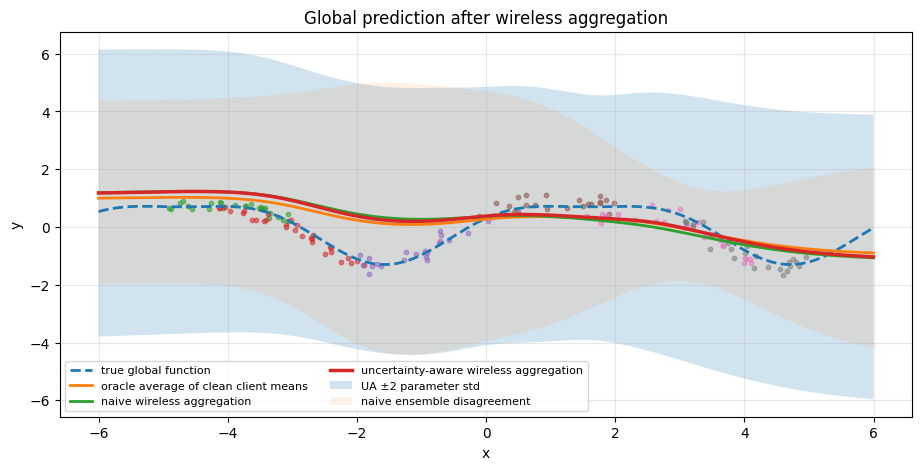

RMSE oracle clean average:         0.6121
RMSE naive wireless aggregation:  0.7331
RMSE uncertainty-aware aggregation:0.6918


In [7]:
mu_received_stack = np.stack([c["mu_received"] for c in clients], axis=0)  # (K, d)
mu_true_stack = np.stack([c["mu"] for c in clients], axis=0)

# Naive equal aggregation of received client means.
mu_naive = mu_received_stack.mean(axis=0)

# Uncertainty-aware aggregation.
eff_vars = []
for c in clients:
    eff_var = np.diag(c["Sigma"]) + c["eq_var"]
    eff_vars.append(eff_var)
eff_vars = np.stack(eff_vars, axis=0)  # (K, d)
precisions = 1.0 / (eff_vars + 1e-10)
mu_ua = np.sum(precisions * mu_received_stack, axis=0) / np.sum(precisions, axis=0)
var_ua = 1.0 / np.sum(precisions, axis=0)

# For comparison: aggregation with no channel corruption.
mu_oracle = mu_true_stack.mean(axis=0)

# Predictive curves.
mean_naive = Phi_grid @ mu_naive
mean_ua = Phi_grid @ mu_ua
mean_oracle = Phi_grid @ mu_oracle
std_ua = np.sqrt(np.sum((Phi_grid**2) * var_ua[None, :], axis=1))

# Ensemble disagreement across received local models.
local_received_preds = Phi_grid @ mu_received_stack.T
std_naive_ensemble = local_received_preds.std(axis=1, ddof=1)

plt.figure(figsize=(11, 5))
plt.plot(x_grid, y_true, linestyle="--", linewidth=2, label="true global function")
plt.plot(x_grid, mean_oracle, linewidth=2, label="oracle average of clean client means")
plt.plot(x_grid, mean_naive, linewidth=2, label="naive wireless aggregation")
plt.plot(x_grid, mean_ua, linewidth=2.5, label="uncertainty-aware wireless aggregation")
plt.fill_between(x_grid, mean_ua - 2 * std_ua, mean_ua + 2 * std_ua, alpha=0.20, label="UA ±2 parameter std")
plt.fill_between(x_grid, mean_naive - 2 * std_naive_ensemble, mean_naive + 2 * std_naive_ensemble, alpha=0.10, label="naive ensemble disagreement")
for c in clients:
    plt.scatter(c["x"], c["y"], s=10, alpha=0.55)
plt.title("Global prediction after wireless aggregation")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(fontsize=8, ncol=2)
plt.show()

rmse_naive = np.sqrt(np.mean((mean_naive - y_true) ** 2))
rmse_ua = np.sqrt(np.mean((mean_ua - y_true) ** 2))
rmse_oracle = np.sqrt(np.mean((mean_oracle - y_true) ** 2))
print(f"RMSE oracle clean average:         {rmse_oracle:.4f}")
print(f"RMSE naive wireless aggregation:  {rmse_naive:.4f}")
print(f"RMSE uncertainty-aware aggregation:{rmse_ua:.4f}")


## 7. How this aggregation connects to Bayesian FL

The local posterior for client $k$ is:

$$
q_k(\theta_k) = \mathcal{N}(\mu_k, \Sigma_k).
$$

The wireless channel adds uncertainty to the transmitted posterior mean:

$$
\widehat{\mu}_k = \mu_k + e_k,
\qquad
e_k \sim \mathcal{N}(0, \sigma_{\mathrm{eq},k}^2 I).
$$

So the server should trust client $k$'s update less when:

$$
\operatorname{diag}(\Sigma_k) \text{ is large}
$$

or when:

$$
\sigma_{\mathrm{eq},k}^2 \text{ is large}.
$$

This is the central research idea:

$$
\boxed{
\text{Aggregation weight should depend on both model uncertainty and communication uncertainty.}
}
$$

## 8. MC-Dropout-style uncertainty on top of the global model

The paper's dropout view says each dropout mask gives a different effective network. Here we demonstrate the mechanism in a simple NumPy way.

We keep the global weights fixed, but apply random masks to hidden features:

$$
z_j \sim \operatorname{Bernoulli}(p),
$$

$$
\Phi_{\mathrm{drop}}(x) = \Phi(x) \odot z.
$$

Multiple masks give multiple predictions:

$$
\hat{y}_1, \ldots, \hat{y}_T.
$$

Mean:

$$
\bar{y} = \frac{1}{T}\sum_{t=1}^{T}\hat{y}_t.
$$

Variance:

$$
\operatorname{Var}(y) = \frac{1}{T-1}\sum_{t=1}^{T}(\hat{y}_t-\bar{y})^2.
$$

This is not a full trained dropout network, but it shows the exact inference mechanics of MC-Dropout.

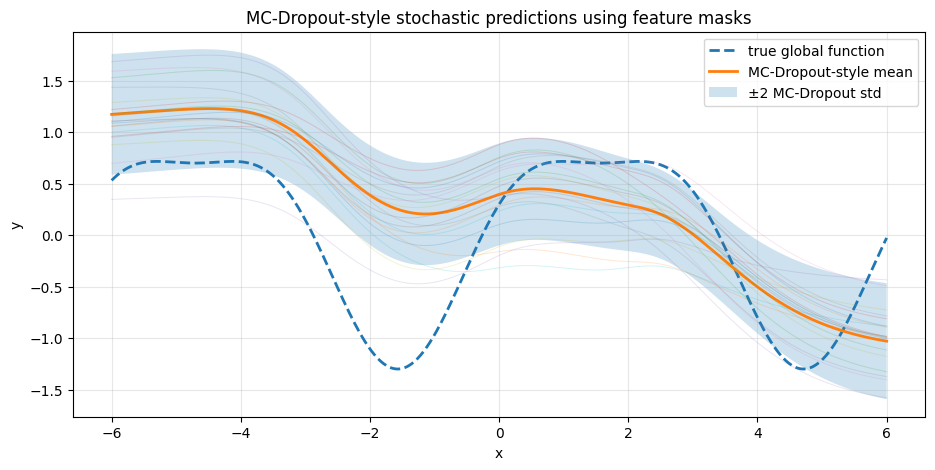

In [8]:
def mc_dropout_feature_predictions(Phi, weights, keep_prob=0.85, T=200, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    n, d = Phi.shape
    preds = np.zeros((n, T))
    for t in range(T):
        mask = rng.binomial(1, keep_prob, size=d).astype(float)
        mask[0] = 1.0  # keep bias feature
        scaled_mask = mask / keep_prob
        scaled_mask[0] = 1.0
        preds[:, t] = Phi @ (weights * scaled_mask)
    return preds

mc_preds = mc_dropout_feature_predictions(Phi_grid, mu_ua, keep_prob=0.85, T=300, rng=rng)
mc_mean = mc_preds.mean(axis=1)
mc_std = mc_preds.std(axis=1, ddof=1)

plt.figure(figsize=(11, 5))
plt.plot(x_grid, y_true, linestyle="--", linewidth=2, label="true global function")
plt.plot(x_grid, mc_mean, linewidth=2, label="MC-Dropout-style mean")
plt.fill_between(x_grid, mc_mean - 2 * mc_std, mc_mean + 2 * mc_std, alpha=0.22, label="±2 MC-Dropout std")
for i in range(20):
    plt.plot(x_grid, mc_preds[:, i], linewidth=0.7, alpha=0.18)
plt.title("MC-Dropout-style stochastic predictions using feature masks")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


## 9. Paperfold-style lesson: why one Gaussian VI can miss multiple modes

The `paperfold-bnn` repository is useful because it compares inference methods on a small model whose posterior can have multiple modes.

This mini-demo is not the original paperfold model. It is a simple visualization of the same lesson:

- MCMC-like samples can cover multiple modes.
- A single Gaussian VI approximation may cover the average region poorly.
- A deep ensemble can represent multiple modes as point masses.
- An ensemble of local Gaussian approximations can represent both mode location and local uncertainty.


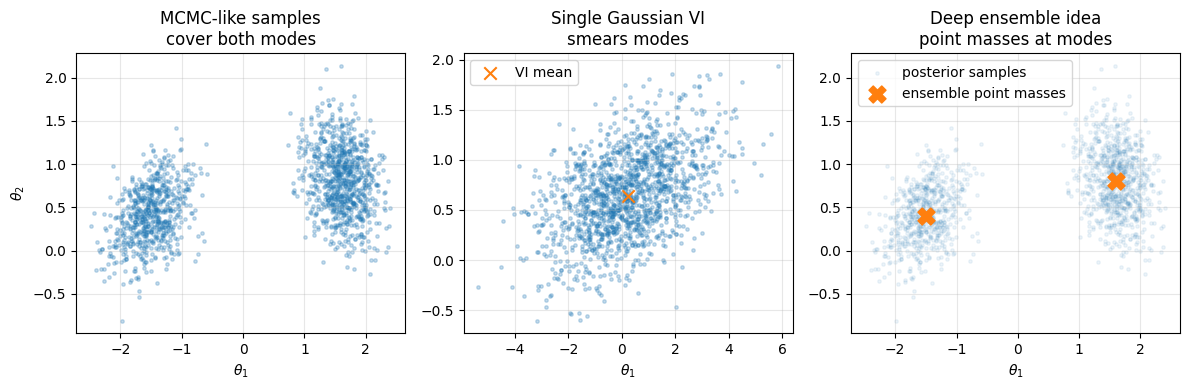

In [9]:
# Synthetic two-mode posterior in a 2D parameter space.
N_samples = 1500
mode_means = np.array([[-1.5, 0.4], [1.6, 0.8]])
mode_covs = np.array([
    [[0.12, 0.04], [0.04, 0.10]],
    [[0.10, -0.03], [-0.03, 0.15]],
])
mode_probs = np.array([0.45, 0.55])
mode_ids = rng.choice(2, size=N_samples, p=mode_probs)
samples = np.zeros((N_samples, 2))
for m in range(2):
    idx = mode_ids == m
    samples[idx] = rng.multivariate_normal(mode_means[m], mode_covs[m], size=idx.sum())

# Single Gaussian VI approximation: match global mean/cov.
vi_mean = samples.mean(axis=0)
vi_cov = np.cov(samples.T)
vi_samples = rng.multivariate_normal(vi_mean, vi_cov, size=N_samples)

# Ensemble point masses at modes.
ensemble_points = mode_means

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.scatter(samples[:, 0], samples[:, 1], s=6, alpha=0.25)
plt.title("MCMC-like samples\ncover both modes")
plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")

plt.subplot(1, 3, 2)
plt.scatter(vi_samples[:, 0], vi_samples[:, 1], s=6, alpha=0.25)
plt.scatter([vi_mean[0]], [vi_mean[1]], s=80, marker="x", label="VI mean")
plt.title("Single Gaussian VI\nsmears modes")
plt.xlabel(r"$\theta_1$")
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(samples[:, 0], samples[:, 1], s=6, alpha=0.08, label="posterior samples")
plt.scatter(ensemble_points[:, 0], ensemble_points[:, 1], s=150, marker="X", label="ensemble point masses")
plt.title("Deep ensemble idea\npoint masses at modes")
plt.xlabel(r"$\theta_1$")
plt.legend()

plt.tight_layout()
plt.show()


## 10. Optional: How to inspect the original repositories

Run these commands in a separate environment if you want to reproduce the authors' original simulations.

```bash
git clone --recursive https://github.com/french-paragon/BayesianNeuralNetwork-Tutorial-Metarepos.git
```

The two most relevant subprojects for your topic are:

```bash
# Conceptual comparison of inference methods
cd BayesianNeuralNetwork-Tutorial-Metarepos/toy-examples/paperfold-bnn
python mcmc_experiment.py -h
python vi_experiment.py -h
python plots.py -h
```

```bash
# BNN layers, MC-Dropout, and noise-aware loss ideas
cd BayesianNeuralNetwork-Tutorial-Metarepos/toy-examples/sparse_measure_bnn
# Study viModel.py first
```

### What to look for in `sparse_measure_bnn/viModel.py`

| Code component | Research meaning |
|---|---|
| `VIModule` | Pattern for attaching Bayesian loss terms to modules |
| `L2RegularizedLinear` | Gaussian prior / L2 regularization |
| `MeanFieldGaussianFeedForward` | Mean-field Gaussian variational posterior and reparameterization |
| Last layers only Bayesian | Low-cost BNN design suitable for FL |
| MC-Dropout calls in `forward` | Cheap approximate Bayesian uncertainty |
| `outlierAwareSumSquareError` | Template for noisy/outlier client-update modeling |

### What to look for in `paperfold-bnn`

| File | Meaning |
|---|---|
| `mcmc_experiment.py` | Generates posterior samples using MCMC |
| `vi_experiment.py` | Generates samples using MAP or mean-field Gaussian VI; ensemble switch available |
| `viModel.py` | MAP and Gaussian VI models |
| `plots.py` | Posterior and predictive visualization |


## 11. Research extensions you can build from this notebook

### Extension A: Bayesian FedAvg with uncertainty-aware weights

Replace standard FedAvg:

$$
\theta_{t+1}=\sum_{k=1}^{K}\frac{n_k}{\sum_j n_j}\theta_{k,t}
$$

with uncertainty-aware aggregation:

$$
\theta_{t+1}
=
\frac{
\sum_k w_k\widehat{\theta}_{k,t}
}{
\sum_k w_k
},
$$

where:

$$
w_k
=
\frac{1}{
\underbrace{u_{k,t}}_{\text{model uncertainty}}
+
\underbrace{c_{k,t}}_{\text{channel uncertainty}}
+
\epsilon
}.
$$

### Extension B: Client-specific Bayesian heads

Use a shared feature extractor and client-specific Bayesian heads:

$$
h=f_{\xi}(x),
\qquad
\theta_k\sim p(\theta_k\mid \xi),
\qquad
 y\sim p(y\mid h,\theta_k).
$$

### Extension C: Robust wireless update likelihood

Use mixture noise for client updates:

$$
\widehat{\Delta}_{k,t}
\sim
(1-\pi_{k,t})\mathcal{N}(\Delta_{k,t},\sigma_{\mathrm{in}}^2I)
+
\pi_{k,t}\mathcal{N}(\Delta_{k,t},\sigma_{\mathrm{out}}^2I).
$$

This is the FL/wireless analogue of the outlier-aware loss idea in `sparse_measure_bnn`.

In [10]:
# Summary variables for later reuse
research_objects = {
    "clients": clients,
    "feature_map": feature_map,
    "x_grid": x_grid,
    "Phi_grid": Phi_grid,
    "mu_naive": mu_naive,
    "mu_uncertainty_aware": mu_ua,
    "var_uncertainty_aware": var_ua,
}

print("Notebook completed.")
print("Reusable objects:")
for key in research_objects:
    print(" -", key)


Notebook completed.
Reusable objects:
 - clients
 - feature_map
 - x_grid
 - Phi_grid
 - mu_naive
 - mu_uncertainty_aware
 - var_uncertainty_aware
